<a href="https://colab.research.google.com/github/sisirak/cv-dl-a1/blob/main/GroupA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section A: Image Processing

##Part 1: Blending Two images  
Objective: Blend two images provided in WebLearn using the specified weight conditions. Analyse
the visual outcomes and discuss the implications of different weight distributions.


###1) Weighted Blending (0.6:0.4 and 0.75:0.25):
####a. Blend two images, imgA.jpg and imgB.jpg, with weights 0.6 and 0.4 respectively.
####b. Blend two images, imgA.jpg and imgB.jpg, with weights 0.75 and 0.25 respectively.
####c. Discuss the visual differences and interpret the impact of weight distribution on the
blended image.

imgB resized to match imgA's dimensions.


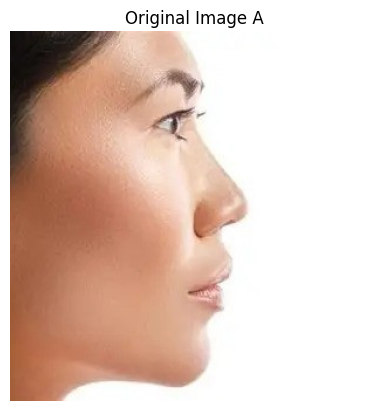

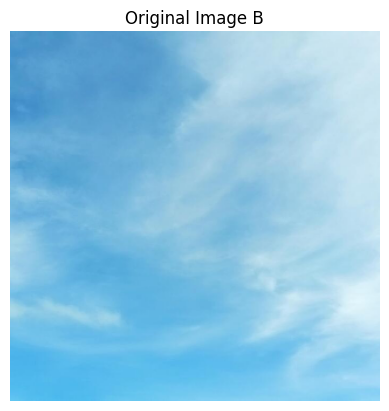

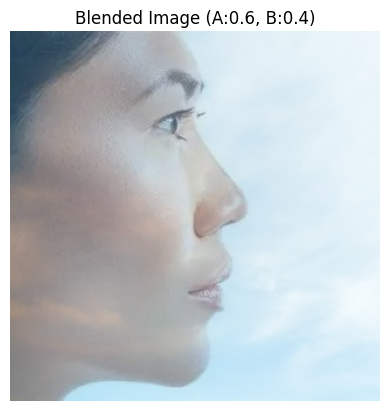

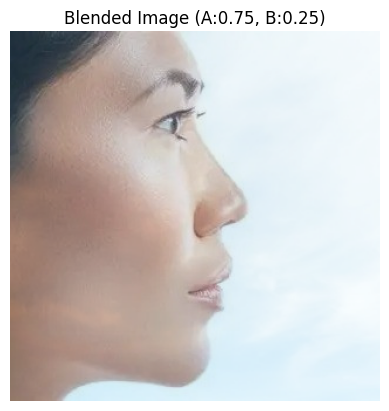

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# Function to display images
def imshow(title, image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

imgA_path = "/content/Image A.jpeg"
imgA = cv2.imread(imgA_path)

imgB_path = "/content/Image B.jpeg"
imgB = cv2.imread(imgB_path)

if imgA is None:
    print(f"Error: imgA.jpg not found or could not be loaded from {imgA_path}")
elif imgB is None:
    print(f"Error: imgB.jpg not found or could not be loaded from {imgB_path}")
else:
    # Resize imgB to match imgA's dimensions if they are different
    if imgA.shape != imgB.shape:
        imgB = cv2.resize(imgB, (imgA.shape[1], imgA.shape[0]))
        print("imgB resized to match imgA's dimensions.")

    # Display original images
    imshow('Original Image A', imgA)
    imshow('Original Image B', imgB)

    # 1a. Blend two images with weights 0.6 and 0.4
    alpha1 = 0.6
    beta1 = 0.4
    blended_image_1 = cv2.addWeighted(imgA, alpha1, imgB, beta1, 0)
    imshow(f'Blended Image (A:{alpha1}, B:{beta1})', blended_image_1)

    # 1b. Blend two images with weights 0.75 and 0.25
    alpha2 = 0.75
    beta2 = 0.25
    blended_image_2 = cv2.addWeighted(imgA, alpha2, imgB, beta2, 0)
    imshow(f'Blended Image (A:{alpha2}, B:{beta2})', blended_image_2)


####1c. Discussion

Visually, the blended image with higher weight for imgA (e.g., 0.75) will appear more like imgA, while a lower weight for imgA (e.g., 0.6) will allow more of imgB to show through. The difference between 0.6:0.4 and 0.75:0.25 blending will be subtle but noticeable, with the 0.75:0.25 blend favoring imgA more strongly.

The impact of weight distribution is direct: a higher weight assigned to an image means its features contribute more significantly to the final blended output, making the blended image closer in appearance to that dominant source image.


###2 Equal Weight Blending (0.5:0.5):

####a. Blend two images, imgA.jpg and imgB.jpg, with equal weights (0.5:0.5).
####b. Evaluate the visual characteristics of the resultant image.
####c. Reflect on the aesthetic and perceptual aspects of equal weight blending.

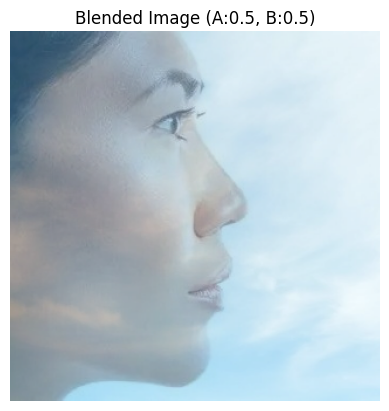

In [ ]:
# 2a. Blend two images with equal weights (0.5:0.5)
alpha3 = 0.5
beta3 = 0.5
blended_image_3 = cv2.addWeighted(imgA, alpha3, imgB, beta3, 0)
imshow(f'Blended Image (A:{alpha3}, B:{beta3})', blended_image_3)

### 2b & 2c. Evaluation and Reflection on Equal Weight Blending

When images are blended with equal weights (0.5:0.5), neither image dominates the other. This typically results in a more balanced fusion where features from both original images are noticeably present, often creating a 'ghosting' or semi-transparent effect for both.

**Visual Characteristics:**
*   **Balance:** There's a clear balance between the contributions of `imgA` and `imgB`. You can usually perceive elements from both source images.
*   **Transparency/Ghosting:** Features from one image might appear superimposed on the other, giving a transparent or ethereal quality.
*   **Reduced Contrast/Saturation:** The overall contrast and color saturation might be lower than the original images as their pixel values are averaged.

**Aesthetic and Perceptual Aspects:**
*   **Dreamlike/Surreal:** Equal blending can create a dreamlike or surreal aesthetic, as reality is blurred and combined.
*   **Information Overload (potentially):** If both images have complex details, the equal blend might become visually cluttered, making it harder to discern specific details from either original image clearly.
*   **Harmonious (potentially):** If the images have complementary compositions or color palettes, equal blending can result in a harmonious and aesthetically pleasing outcome, suggesting continuity or a transition between two scenes.

## Part 2: Histogram Equalization
Objective: Perform histogram equalization on the image `imgC.jpg`. Analyse the visual outcomes and discuss the enhancements achieved through histogram equalization.


1) Image Transformation:

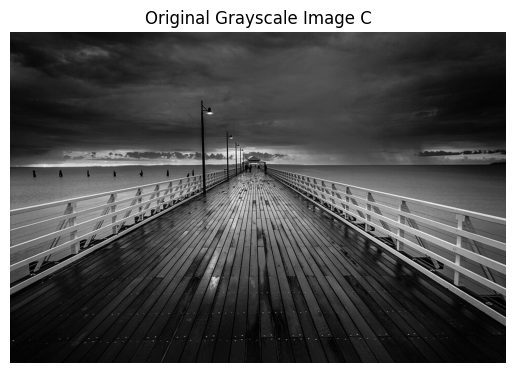

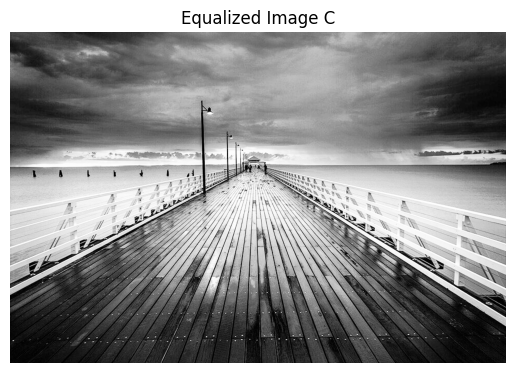

In [ ]:
imgC_path = "/content/Image C.jpeg"
imgC = cv2.imread(imgC_path, cv2.IMREAD_GRAYSCALE)

if imgC is None:
    print(f"Error: imgC.jpg not found or could not be loaded from {imgC_path}")
else:
    # Display original grayscale image
    imshow('Original Grayscale Image C', imgC)

    # 1a. Apply histogram equalization to imgC.jpg
    equalized_imgC = cv2.equalizeHist(imgC)

    # Display equalized image
    imshow('Equalized Image C', equalized_imgC)

#### 1b. Discussion: Visual Improvements and Interpretation
With the specific image loaded, it improves the visibility of the caracteristics of the image.

####1c. Provide the histogram results before and after equalization


/tmp/ipykernel_3296/175222603.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(imgC.flatten(), 256, [0, 256], color='r')
/tmp/ipykernel_3296/175222603.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized_imgC.flatten(), 256, [0, 256], color='g')


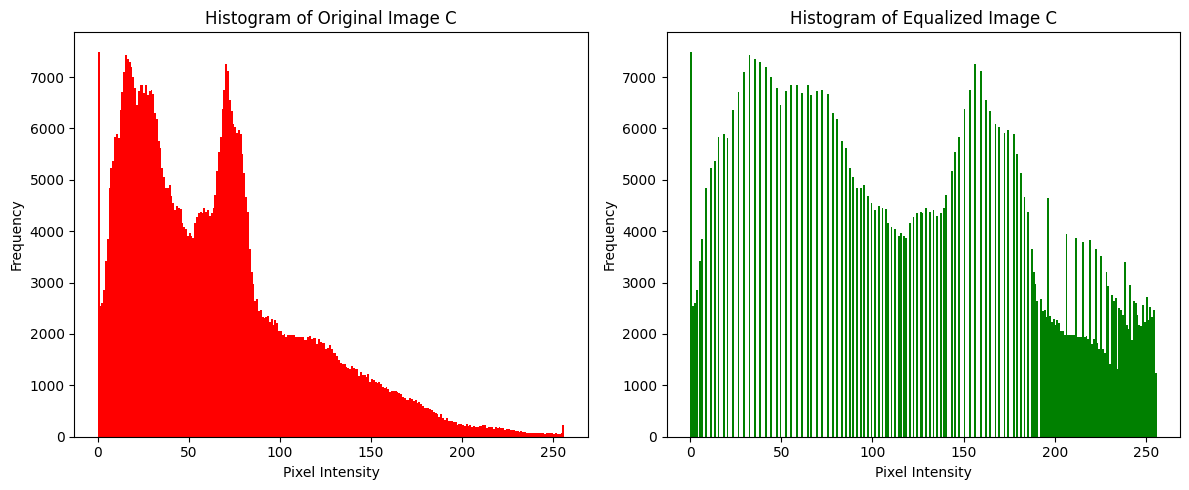

In [ ]:
plt.figure(figsize=(12, 5))

# Histogram of original image
plt.subplot(1, 2, 1)
plt.hist(imgC.flatten(), 256, [0, 256], color='r')
plt.title('Histogram of Original Image C')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

# Histogram of equalized image
plt.subplot(1, 2, 2)
plt.hist(equalized_imgC.flatten(), 256, [0, 256], color='g')
plt.title('Histogram of Equalized Image C')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1d. Reflection on Potential Applications of Histogram Equalization

Histogram equalization enhances the contrast of an image by spreading out the most frequent pixel intensity values. This is particularly useful for images where the pixel intensities are clustered in a narrow range, leading to a dull or washed-out appearance.

**Visual Improvements:**
*   **Increased Contrast:** The most noticeable improvement is typically an increase in contrast, making details more discernible in both dark and bright areas.
*   **Brighter Images:** Often, images will appear brighter and more vivid.

**Interpretation of Results:**
*   The histogram of the original image will likely show a concentration of pixel values in certain ranges.
*   The histogram of the equalized image, in contrast, will have a more uniform distribution of pixel values across the entire intensity range (0-255).

**Potential Applications:**
*   **Medical Imaging:** Enhancing X-rays or MRI scans to highlight subtle features.
*   **Satellite Imaging:** Improving visibility of geological features or urban areas in low-contrast satellite photos.
*   **Photography:** Correcting underexposed or overexposed images.
*   **Security and Surveillance:** Making details clearer in surveillance footage captured in challenging lighting conditions.
*   **Computer Vision Pre-processing:** As a pre-processing step to improve the performance of other image processing algorithms that rely on good contrast, such as edge detection or object recognition.

## Part 3: Image Processing techniques

Objective: This section aims to provide hands-on experience in advanced image processing techniques. You will apply concepts to perform a series of tasks on `imgC.jpg`.

### 1) Brightness Adjustment:
####a. Increase the brightness of the original image and display the transformed images.
####b. Experiment with different levels of brightness adjustments, illustrating dynamic image enhancement.

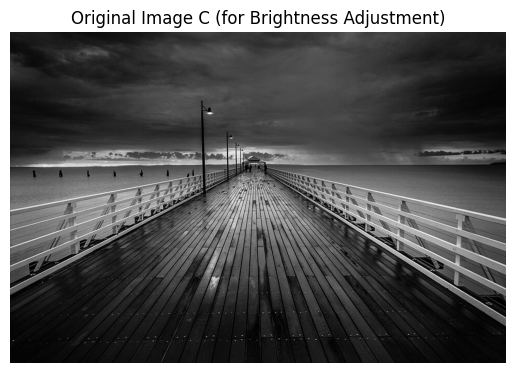

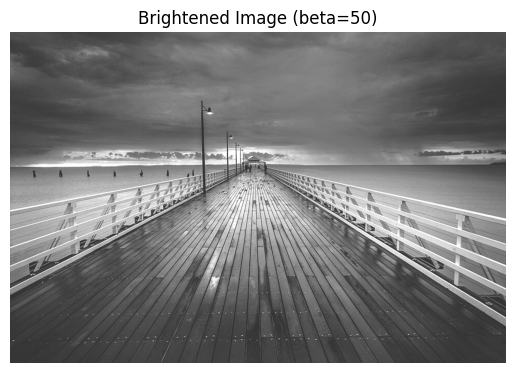

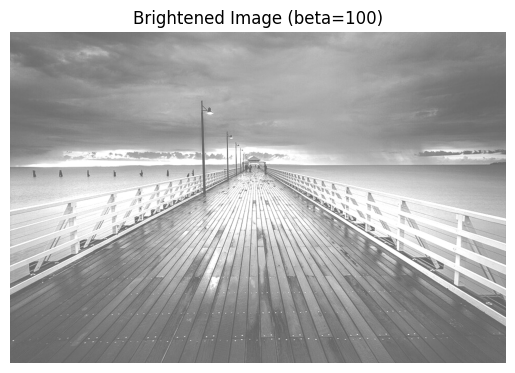

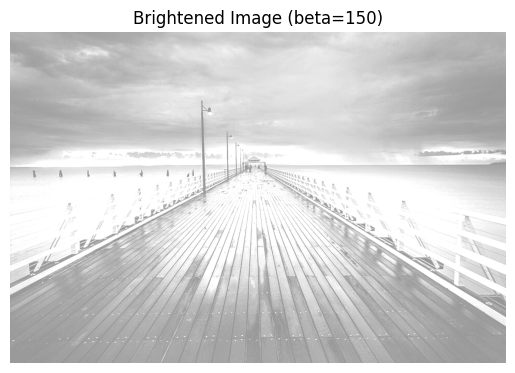

In [ ]:
# Ensure imgC is in BGR format for consistent display if it was loaded grayscale
if len(imgC.shape) == 2:
    imgC_display = cv2.cvtColor(imgC, cv2.COLOR_GRAY2BGR)
else:
    imgC_display = imgC.copy()

imshow('Original Image C (for Brightness Adjustment)', imgC_display)

brightness_levels = [50, 100, 150] # Experiment with different beta values

for beta_val in brightness_levels:
    # For grayscale, direct addition works well. For color, convertScaleAbs is often preferred.
    brightened_img = cv2.add(imgC, beta_val) # For grayscale

    # Display the brightened image
    imshow(f'Brightened Image (beta={beta_val})', brightened_img)


**Discussion:** Increasing the beta value in the brightness adjustment adds a constant value to each pixel, making the image appear brighter. As beta increases, the image becomes progressively brighter. If the image contains very dark areas, they become more visible. However, increasing brightness too much can lead to loss of detail in already bright areas (saturation).

### 2) Image Flipping:
a. Flip the original image horizontally.
b. Flip the original image vertically.
c. Discuss the impact of flipping operations on image orientation.

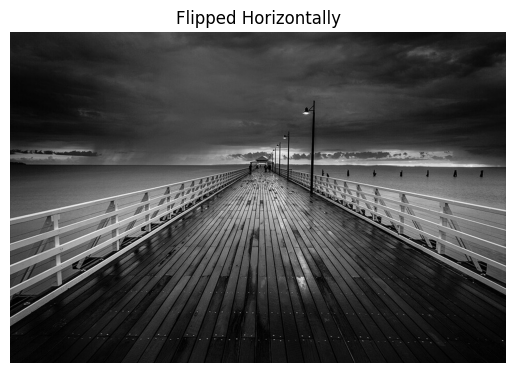

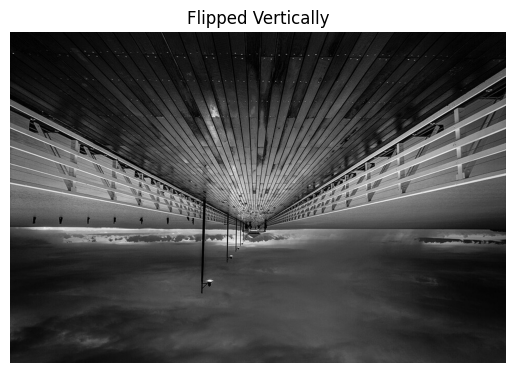

In [ ]:
# 2a. Flip the original image horizontally
# Ensure imgC is in BGR for display if it was loaded grayscale
if len(imgC.shape) == 2:
    imgC_color = cv2.cvtColor(imgC, cv2.COLOR_GRAY2BGR)
else:
    imgC_color = imgC.copy()

# Horizontal flip (flipCode = 1)
flipped_horizontal = cv2.flip(imgC_color, 1)
imshow('Flipped Horizontally', flipped_horizontal)

# 2b. Flip the original image vertically
# Vertical flip (flipCode = 0)
flipped_vertical = cv2.flip(imgC_color, 0)
imshow('Flipped Vertically', flipped_vertical)


Discussion: Impact of Flipping Operations

Flipping an image changes its orientation along a specified axis. A horizontal flip mirrors the image from left to right, effectively swapping the left and right halves. A vertical flip mirrors the image from top to bottom, swapping the top and bottom halves. These operations are fundamental for augmenting datasets in machine learning, correcting image orientation, or creating stylistic effects.


### 3) Image Rotation:
a. Rotate the original image 90 degrees clockwise.
b. Analyse the rotated image and discuss potential applications.

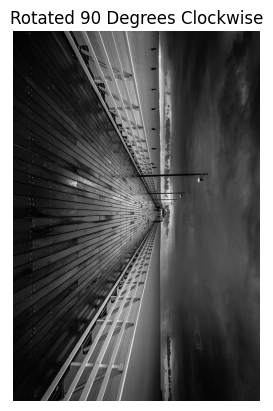

In [ ]:
# Ensure imgC is in BGR for display if it was loaded grayscale
if len(imgC.shape) == 2:
    imgC_color = cv2.cvtColor(imgC, cv2.COLOR_GRAY2BGR)
else:
    imgC_color = imgC.copy()

rotated_image_90_cw = cv2.rotate(imgC_color, cv2.ROTATE_90_CLOCKWISE)
imshow('Rotated 90 Degrees Clockwise', rotated_image_90_cw)


Discussion: Analysis and Applications of Rotated Image

Rotating an image changes its spatial orientation without altering its content. A 90-degree clockwise rotation shifts the top edge to the right, the right edge to the bottom, and so on. This operation is crucial for standardizing image orientations (e.g., correcting photos taken sideways), artistic effects, or as a data augmentation technique in computer vision to make models robust to variations in object orientation. The dimensions of the image may change if it's not square after rotation.

# Section B: Deep Learning Model  

## Installing required packages and importing

In [1]:
!pip install roboflow opencv-python matplotlib
!pip install --upgrade roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import os
from tensorflow.keras.preprocessing import image as keras_image
import pandas as pd
import shutil

## Download data

This cell is responsible for downloading the dataset from Roboflow, but with a clever check to avoid re-downloading if it's already present. Here's a breakdown:

First, it imports Roboflow to interact with the Roboflow platform and os for interacting with the operating system, like checking for file existence.

Next, it defines dataset_path as /content/PPE-Dataset-for-Workplace-Safety-1. This is the expected location where the dataset will be stored.

The core logic is an if statement: if not os.path.exists(dataset_path):. This checks if the directory specified by dataset_path does not exist. If the directory is not found, it proceeds to:

Initialize Roboflow with your API key.
Access your specific project ('ppe-dataset-for-workplace-safety') from your workspace ('siabar').
Select version 1 of the dataset.
Download the dataset in TensorFlow format.
If the dataset_path directory does exist, it skips the download process and simply prints a message indicating that the dataset is already downloaded. This prevents unnecessary downloads and saves time if you run the notebook multiple times.



In [9]:
from roboflow import Roboflow
import os

# Define the expected path of the downloaded dataset
dataset_path = "/content/PPE-Dataset-for-Workplace-Safety-1"

# Check if the dataset directory already exists
if not os.path.exists(dataset_path):
    from roboflow import Roboflow
    rf = Roboflow(api_key="bUQGGySJva2Z46dq4OQE")
    project = rf.workspace("siabar").project("ppe-dataset-for-workplace-safety")
    version = project.version(1)
    dataset = version.download("tensorflow")

else:
    print(f"Dataset already downloaded to {dataset_path}. Skipping download.")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Dataset-for-Workplace-Safety-1 in tensorflow:: 100%|██████████| 1612/1612 [00:00<00:00, 3158.93it/s]


## Classifying the data set as per the requirement

This cell is crucial for organizing your downloaded dataset into a structure that TensorFlow's image_dataset_from_directory utility can easily understand. Essentially, it takes the raw Roboflow dataset with its annotation CSVs and sorts the images into helmet and no_helmet subdirectories for each split (train, valid, test).

Here's a breakdown of what the code does:

Imports: It begins by importing pandas for reading CSV files, os for interacting with the operating system (like creating directories and joining paths), and shutil for file operations (like copying).

Define Paths: It sets base_data_dir to /content/PPE-Dataset-for-Workplace-Safety-1, which is where your Roboflow dataset was downloaded. It also defines dataset_types as a list containing "train", "valid", and "test" to iterate through each data split.

Loop Through Dataset Splits: The code then enters a loop, processing each of the "train", "valid", and "test" datasets one by one.

Idempotency Check: Inside the loop, before doing any work, it performs an important check: if os.path.exists(helmet_check_dir) and os.listdir(helmet_check_dir) and os.path.exists(no_helmet_check_dir) and os.listdir(no_helmet_check_dir):. This verifies if the helmet and no_helmet subdirectories already exist within the current split's path and if they contain files. If they do, it assumes the reorganization has already been done for that split and skips it, preventing redundant operations (this is why you saw 'Skipping reorganization' in the output).

Locate and Read Annotations: If the directories don't exist or are empty, it constructs the annotations_csv_path (e.g., /content/PPE-Dataset-for-Workplace-Safety-1/train/label/_annotations.csv). It checks if this CSV file exists and then uses pandas.read_csv to load the bounding box and class information for all images in that split. It also assigns meaningful column names like filename, class, etc.

Create Output Directories: It then creates the helmet/ and no_helmet/ subdirectories within the current split's directory if they don't already exist. These are the target folders where the images will be moved.

Sort Images:

It groups the annotations by filename, meaning it considers all annotations belonging to a single image together.
For each image, it checks if any of its annotations contain the class "Helmet".
It determines the source path of the image (src).
Finally, it uses shutil.copy to copy the image file. If the image contains a "Helmet" annotation, it's copied to the helmet_dir; otherwise, it's copied to the no_helmet_dir.
Completion Message: After processing all images for a given split, it prints a message confirming the sorting. Once all splits are processed, a final message "All specified datasets processed." is displayed.

In essence, this script transforms a dataset structured with a single directory of images and an annotation CSV into a more conventional image classification dataset structure, with images categorized into class-specific subfolders. This is a common preprocessing step when using utilities like tf.keras.utils.image_dataset_from_directory.

In [10]:
import pandas as pd # Import pandas for reading CSV files
import os
import shutil

# The Roboflow download output indicated the dataset was extracted to 'PPE-Dataset-for-Workplace-Safety-1'.
# We explicitly set base_data_dir to this path.
base_data_dir = "/content/PPE-Dataset-for-Workplace-Safety-1"

dataset_types = ["train", "valid", "test"] # Iterate over all three dataset splits

for ds_type in dataset_types:
    print(f"Processing {ds_type} dataset...")
    current_split_path = os.path.join(base_data_dir, ds_type)
    classified_path = os.path.join(base_data_dir, "classified", ds_type)

    # Check if the 'helmet' and 'no_helmet' directories already exist and contain files.
    # If they do, assume the classification has already been done for this split.
    helmet_check_dir = os.path.join(current_split_path, "helmet")
    no_helmet_check_dir = os.path.join(current_split_path, "no_helmet")

    if os.path.exists(helmet_check_dir) and os.listdir(helmet_check_dir) and \
       os.path.exists(no_helmet_check_dir) and os.listdir(no_helmet_check_dir):
        print(f"'helmet' and 'no_helmet' directories already exist and contain files in {ds_type}. Skipping reorganization.")
        continue

    # Based on the `ls` command output, _annotations.csv is directly in the split directory
    annotations_csv_path = os.path.join(current_split_path, "_annotations.csv")

    if not os.path.exists(annotations_csv_path):
        print(f"Annotations CSV not found for {ds_type} at {annotations_csv_path}. Skipping this split.")
        continue

    # Load the CSV (Roboflow annotation format)
    df_annotations = pd.read_csv(annotations_csv_path, header=None)
    df_annotations.columns = ["filename", "width", "height", "class", "xmin", "ymin", "xmax", "ymax"]

    # Create output folders within the current dataset type directory
    helmet_dir = os.path.join(classified_path, "helmet")
    no_helmet_dir = os.path.join(classified_path, "no_helmet")

    os.makedirs(helmet_dir, exist_ok=True)
    os.makedirs(no_helmet_dir, exist_ok=True)

    # Group by image filename
    grouped = df_annotations.groupby("filename")

    for filename, group in grouped:
        # Determine if this image contains a helmet
        # Assuming 'Helmet' is the class name for helmet in the annotations
        has_helmet = "Helmet" in group["class"].values

        # Source image path (Based on `ls` command, images are directly in the split directory)
        src = os.path.join(current_split_path, filename)

        # Skip if file does not exist (safety check)
        if not os.path.exists(src):
            print(f"Missing image: {filename} in {ds_type} dataset. Skipping.")
            continue

        # Copy to correct folder
        if has_helmet:
            shutil.copy(src, helmet_dir)
        else:
            shutil.copy(src, no_helmet_dir)

    print(f"Images for {ds_type} dataset successfully sorted into 'helmet/' and 'no_helmet/' subdirectories.")

print("All specified datasets processed.")

Processing train dataset...
Missing image: filename in train dataset. Skipping.
Images for train dataset successfully sorted into 'helmet/' and 'no_helmet/' subdirectories.
Processing valid dataset...
Missing image: filename in valid dataset. Skipping.
Images for valid dataset successfully sorted into 'helmet/' and 'no_helmet/' subdirectories.
Processing test dataset...
Missing image: filename in test dataset. Skipping.
Images for test dataset successfully sorted into 'helmet/' and 'no_helmet/' subdirectories.
All specified datasets processed.


## Dataset Loading

This cell is responsible for loading your image datasets (training, validation, and test) using TensorFlow's utilities after they have been reorganized. It sets up key parameters for image processing and batching.

Here's a breakdown:

Constants:

IMG_SIZE = (224, 224): This defines the target dimensions for all images. They will be resized to 224 pixels by 224 pixels, which is a common input size for many pre-trained convolutional neural networks like MobileNetV2.
BATCH_SIZE = 32: This specifies the number of images that will be processed in one go by the model during training. Processing data in batches is efficient for GPUs.
SEED = 42: This sets a random seed for reproducibility. When shuffle=True is used, setting a seed ensures that the shuffling order is the same every time you run the code.
base_data_dir:

base_data_dir = "/content/PPE-Dataset-for-Workplace-Safety-1": This variable stores the root directory where your dataset is located. This path assumes the dataset was downloaded and then reorganized into 'helmet' and 'no_helmet' subdirectories within the 'train', 'valid', and 'test' folders.
Loading Datasets with tf.keras.utils.image_dataset_from_directory: This function is a convenient way to load image data from a directory structure where subdirectories correspond to classes.

train_ds (Training Dataset):
os.path.join(base_data_dir, "train"): Points to the training data directory.
image_size=IMG_SIZE: Resizes all images to 224x224 pixels.
batch_size=BATCH_SIZE: Groups images into batches of 32.
seed=SEED: Ensures reproducible shuffling.
shuffle=True: Shuffles the training data, which is important for model generalization.
val_ds (Validation Dataset): Loaded similarly from the valid directory, but shuffle=False because validation data doesn't need to be shuffled.
test_ds (Test Dataset): Loaded similarly from the test directory, also with shuffle=False.
Extracting Class Information:

class_names = train_ds.class_names: After loading, image_dataset_from_directory automatically infers the class names from the subdirectory names (e.g., 'helmet', 'no_helmet'). These are stored in class_names.
num_classes = len(class_names): Calculates the total number of unique classes.
Printing Information:

The cell then prints the Number of classes and the Class names it detected, confirming the setup for your classification task. In your case, it correctly identified 2 classes: 'helmet' and 'no_helmet'.
In essence, this cell prepares your image data, making it ready to be fed into your neural network for training and evaluation by organizing it into TensorFlow Dataset objects.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# data path should point to the downloaded Roboflow dataset after reorganization
# This path assumes the dataset was downloaded to '/content/PPE-Dataset-for-Workplace-Safety-1'
base_data_dir = "/content/PPE-Dataset-for-Workplace-Safety-1/classified"

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_data_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_data_dir, "valid"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_data_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")


Found 1120 files belonging to 2 classes.
Found 326 files belonging to 2 classes.
Found 161 files belonging to 2 classes.
Number of classes: 2
Class names: ['helmet', 'no_helmet']


## Preprocessing

This cell is critical for preparing your image datasets (train_ds, val_ds, test_ds) for efficient training with a pre-trained model like MobileNetV2. It applies several transformations to optimize the data pipeline.

###preprocess function:

image = tf.cast(image, tf.float32): This line converts the pixel values of the image from their original data type (often uint8 for 0-255 values) to float32. Neural networks typically perform calculations on floating-point numbers.
image = preprocess_input(image): This is a very important step specifically for models pre-trained on ImageNet (like MobileNetV2). The preprocess_input function (imported from tensorflow.keras.applications.mobilenet_v2) takes the raw pixel values (now float32) and scales them to a specific range, typically [-1, 1], which is the range that MobileNetV2 expects because it was trained with data normalized this way. Using this function ensures your input data matches the model's expectations.
return image, label: The function returns the preprocessed image along with its original label.
AUTOTUNE = tf.data.AUTOTUNE:

AUTOTUNE is a TensorFlow constant that allows the tf.data API to automatically determine the optimal number of parallel calls for data transformations based on your available CPU resources. It helps in maximizing pipeline performance.
Applying transformations to datasets:

.map(preprocess): This applies the preprocess function to every image and label pair in your datasets. So, all images are converted to float32 and normalized to the [-1, 1] range.
.cache(): After the first epoch, this caches the elements of the dataset in memory (or on local disk if memory is insufficient). This is beneficial because the preprocess function is only executed once per element, and subsequent passes (epochs) will load the preprocessed data much faster.
.shuffle(1000) (for train_ds only): This shuffles the training dataset with a buffer size of 1000. Shuffling is crucial for training data to prevent the model from learning the order of samples, which helps improve generalization and prevents oscillations during training. The 1000 means it will randomly pick elements from a buffer of 1000 samples.
.prefetch(AUTOTUNE): This transformation allows your data loading pipeline to fetch batches of data in the background while your model is busy training on the current batch. This ensures that the GPU (or CPU) is never waiting for data, preventing bottlenecks and significantly speeding up training time. AUTOTUNE helps optimize this prefetching behavior.
In summary, this cell ensures that your image data is correctly formatted, efficiently loaded, and presented to the neural network in a way that maximizes training speed and model performance.

In [12]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(preprocess).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).cache().prefetch(AUTOTUNE)

## Data Augmentation

This cell defines a keras.Sequential model for data augmentation. Data augmentation is a crucial technique in training deep learning models, especially with images. It artificially expands the size of your training dataset by creating modified versions of existing images. This helps prevent overfitting and improves the model's ability to generalize to new, unseen data.

data_augmentation = keras.Sequential([...], name="data_augmentation"):

This creates a Sequential model, which is a linear stack of layers. In this case, the 'layers' are various data augmentation operations.
The name="data_augmentation" simply assigns a name to this sequence of operations, which can be useful for debugging or integrating it into a larger model.
layers.RandomFlip("horizontal"):

This layer randomly flips images horizontally. For example, if an image contains a person looking right, this layer might flip it so the person is looking left. This is a common and effective augmentation as many objects are symmetrical or their orientation (left/right) doesn't change their class.
layers.RandomRotation(0.05):

This layer randomly rotates images by a certain factor. The 0.05 here means that images will be rotated by a random angle within the range of [-0.05 * 2π, 0.05 * 2π] radians (or approximately [-18°, 18°] degrees). This helps the model become more robust to slight variations in object orientation.
layers.RandomContrast(0.1):

This layer randomly adjusts the contrast of the images. The 0.1 factor means the contrast will be randomly scaled by a factor within [1 - 0.1, 1 + 0.1] (i.e., [0.9, 1.1]). This helps the model become less sensitive to variations in lighting conditions.
When this data_augmentation model is applied to your training images, each image will undergo a different set of these random transformations, making your model more robust and less prone to memorizing the exact training examples.

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.1),
], name="data_augmentation")


##Class Weights

The selected code class_weight='balanced' is a parameter used within the compute_class_weight function. This function from sklearn.utils.class_weight calculates weights for each class in your dataset.

When class_weight is set to 'balanced', it automatically adjusts the weights to be inversely proportional to the class frequencies in the input data (y_train). This means that classes with fewer samples (minority classes) will be assigned higher weights, and classes with more samples (majority classes) will be assigned lower weights.

The main purpose of this is to combat class imbalance. If your training data has significantly more examples of one class than another (e.g., many more 'no_helmet' images than 'helmet' images), a model trained without these weights might become biased towards predicting the majority class. By using balanced class weights, you ensure that the model gives more importance to the less frequent classes during training, which can lead to better overall performance and fairer predictions across all classes.

In [14]:
y_train = np.concatenate([y.numpy() for _, y in train_ds.unbatch().batch(1000)])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

##Model Builder Function

This cell defines a Python function called build_model that constructs and compiles a convolutional neural network (CNN) for image classification. This model uses a pre-trained MobileNetV2 as its base feature extractor, on top of which custom layers are added for classification. It's designed to be flexible with hyperparameters like learning rate, dropout, and L2 regularization.

###Function Definition:

The build_model(lr, dropout_rate, l2_value) function creates and compiles a transfer learning image classification model using MobileNetV2. It accepts three hyperparameters: the learning rate (lr), dropout rate (dropout_rate) to reduce overfitting, and L2 regularization strength (l2_value) for weight regularization.

The model uses **MobileNetV2** as a pre-trained feature extractor with ImageNet weights. The input image size is defined as IMG_SIZE + (3,), representing RGB images. By setting include_top=False, the original classification layers of MobileNetV2 are removed so custom layers can be added. Initially, base_model.trainable = False freezes the pre-trained weights, allowing only the new layers to be trained during the first training phase.

The custom model begins with an input layer matching the image dimensions. Data augmentation is applied to improve robustness through transformations such as flipping, rotation, and contrast changes. The augmented images are then passed through the frozen MobileNetV2 model using training=False to keep batch normalization behavior stable.

The extracted feature maps are reduced using GlobalAveragePooling2D, which converts them into a compact feature vector while reducing parameters. Dropout is applied to reduce overfitting. A dense hidden layer with 256 neurons and ReLU activation is added, along with L2 regularization to penalize large weights. Another dropout layer is added for additional regularization.

The output layer and loss function are selected dynamically based on the number of classes:

* For **binary classification** (num_classes == 2), the model uses:

  * A single output neuron with **sigmoid** activation
  * **binary_crossentropy** loss

* For **multi-class classification**, the model uses:

  * A Dense(num_classes) layer with **softmax** activation
  * **sparse_categorical_crossentropy** loss

Finally, the model is created using keras.Model(inputs, outputs) and compiled with:

* **Adam optimizer** using the specified learning rate
* The selected loss function
* **Accuracy** as the evaluation metric

The function returns a fully compiled Keras model ready for training. Overall, it provides a flexible transfer learning framework for image classification while enabling easy tuning of important hyperparameters.


In [15]:
def build_model(lr, dropout_rate, l2_value):
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_value)
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation="sigmoid")(x)
        loss_fn = "binary_crossentropy"
    else:
        outputs = layers.Dense(num_classes, activation="softmax")(x)
        loss_fn = "sparse_categorical_crossentropy"

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    return model

##Early Stopping

This code defines an EarlyStopping callback for training a Keras model. Early stopping is a crucial technique to prevent overfitting and save training time.

keras.callbacks.EarlyStopping: This initializes the early stopping functionality.
monitor="val_loss": This tells the callback to keep an eye on the validation loss (val_loss) during training. The goal is usually to minimize this metric.
patience=3: If the monitored quantity (validation loss in this case) does not improve for 4 consecutive epochs, the training will be stopped early. For example, if the validation loss stops decreasing for 4 epochs, training will halt.
restore_best_weights=True: If training stops early, this parameter ensures that the model's weights are reverted to the epoch where the best monitored value (lowest val_loss) was achieved. This way, you don't end up with a model that has started to overfit just before stopping.

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

##Hyperparameter Experiments

This code sets up and runs multiple hyperparameter experiments for your deep learning model. First, experiment_configs defines different combinations of learning rates, dropout rates, and L2 regularization values to test. Then, it iterates through each configuration. In each iteration, it builds a new model using the build_model function with the specified hyperparameters. It then trains this model for up to 10 epochs using your training data (train_ds) and validates it on val_ds. It also incorporates class weights to handle imbalanced datasets and uses early stopping to prevent overfitting. Finally, it stores the training history and the trained model from each experiment for later analysis.

In [17]:
experiment_configs = [
    {"lr": 1e-3, "dropout": 0.3, "l2": 1e-4},
    {"lr": 5e-4, "dropout": 0.5, "l2": 1e-4},
    {"lr": 1e-4, "dropout": 0.3, "l2": 1e-3},
]

experiment_histories = []
experiment_models = []

for cfg in experiment_configs:
    model = build_model(cfg["lr"], cfg["dropout"], cfg["l2"])
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        class_weight=class_weights,
        callbacks=[early_stop]
    )
    experiment_histories.append(history)
    experiment_models.append(model)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7223 - loss: 0.5887 - val_accuracy: 0.8374 - val_loss: 0.3785
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8491 - loss: 0.3807 - val_accuracy: 0.8834 - val_loss: 0.2992
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8902 - loss: 0.2985 - val_accuracy: 0.8865 - val_loss: 0.2988
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.8955 - loss: 0.2858 - val_accuracy: 0.9264 - val_loss: 0.2601
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9214 - loss: 0.2539 - val_accuracy: 0.9049 - val_loss: 0.2661
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9009 - loss: 0.2577 - val_accuracy: 0.9110 - val_loss: 0.2532
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9259 - loss: 0.2085 - val_accuracy: 0.8988 - val_loss: 0.2620
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9277 

##Choose Best Model (highest val accuracy)

This code block is used to select the best-performing model from the hyperparameter tuning experiments you just ran.

[max(h.history["val_accuracy"]) for h in experiment_histories]: During the hyperparameter tuning phase, you trained several models, and their training logs (histories) were stored in experiment_histories. This part of the code iterates through each training history (h) and extracts the maximum validation accuracy (val_accuracy) achieved by that model across all its training epochs. This creates a list of the peak validation accuracies for each experiment.

best_idx = np.argmax(...): np.argmax() is a NumPy function that returns the index of the largest value in a list. So, best_idx will store the index of the experiment that yielded the highest peak validation accuracy among all the experiments.

model = experiment_models[best_idx]: Finally, experiment_models contains all the trained Keras models, corresponding to the histories in experiment_histories. This line uses the best_idx to retrieve and assign the actual Keras model that achieved the highest validation accuracy to the model variable. This model will then be used for subsequent steps like fine-tuning, evaluation, and deployment.

In [18]:
best_idx = np.argmax([max(h.history["val_accuracy"]) for h in experiment_histories])
model = experiment_models[best_idx]

##Fine-Tuning

This code block is performing the fine-tuning phase of your model training. First, it identifies the pre-trained MobileNetV2 base model within your overall model architecture. It then sets this base model to be trainable, meaning its weights can now be updated. Next, it selectively freezes the first 50 layers of the base model, while allowing the remaining deeper layers to be trained. The model is then recompiled with a very small learning rate (1e-5), which is crucial for fine-tuning, and the appropriate loss function. Finally, the model is trained for additional epochs using your training data, validation data, class weights, and early stopping, capturing the training history in fine_tune_history.

In [21]:
base_model = model.get_layer("mobilenetv2_1.00_224")
base_model.trainable = True

fine_tune_at = 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy" if num_classes == 2 else "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.8741 - loss: 0.3225 - val_accuracy: 0.8896 - val_loss: 0.2754
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.8768 - loss: 0.2948 - val_accuracy: 0.8896 - val_loss: 0.2849
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9152 - loss: 0.2543 - val_accuracy: 0.8896 - val_loss: 0.2881
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9232 - loss: 0.2261 - val_accuracy: 0.8896 - val_loss: 0.3010
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9366 - loss: 0.2021 - val_accuracy: 0.8834 - val_loss: 0.3077


## Visualization of the Accuracy and Loss improvement.

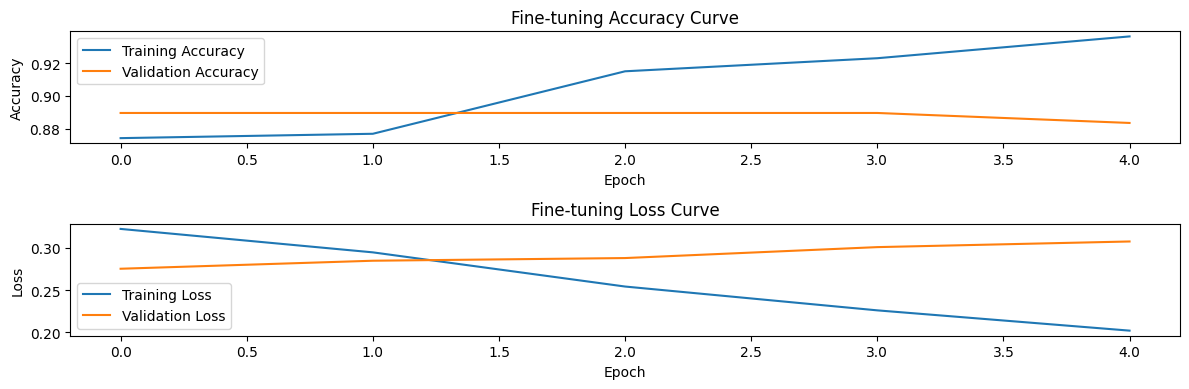

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.plot(fine_tune_history.history['accuracy'], label='Training Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-tuning Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(fine_tune_history.history['loss'], label='Training Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.title('Fine-tuning Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,591,749 (28.96 MB)

 Trainable params: 2,502,785 (9.55 MB)

 Non-trainable params: 83,392 (325.75 KB)

 Optimizer params: 5,005,572 (19.09 MB)

##Save Model

This line of code, model.save("ppe_classifier_mobilenetv2.keras"), is used to save your trained Keras model to a file named ppe_classifier_mobilenetv2.keras.

Saving the Model's State: It saves the entire state of the model, including:

The model's architecture (how the layers are put together).
The trained weights (the learned parameters of the network).
The training configuration (optimizer, loss function, and metrics you used).
The state of the optimizer, allowing you to resume training exactly where you left off if needed.
File Format: The .keras extension indicates that it's being saved in the native Keras v3 format, which is a modern, recommended way to save Keras models. This format is a self-contained archive that stores all necessary information.

Reusability: Once saved, you can later load this model using tf.keras.models.load_model('ppe_classifier_mobilenetv2.keras') without having to retrain it. This is essential for deploying your model, making predictions on new data, or continuing training at a later time.

In [23]:
model.save("ppe_classifier_mobilenetv2.keras")

## Evaluation on Test Set

This code evaluates your trained machine learning model on the test_ds (test dataset) to assess its performance on unseen data.

test_loss, test_acc = model.evaluate(test_ds): The model.evaluate() method takes your test dataset and computes two key metrics: the test_loss and the test_acc (test accuracy).

test_loss: This is the value of the loss function on the test data. A lower loss generally indicates a better-performing model.
test_acc: This is the accuracy of your model on the test data. It represents the proportion of correctly classified examples in the test set.
print("Test accuracy:", test_acc): This line simply prints the calculated test accuracy to the console. Evaluating the model on a separate test set is crucial for understanding how well your model generalizes to new, real-world data it hasn't seen during training or validation.

In [24]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 838ms/step - accuracy: 0.9317 - loss: 0.2704
Test accuracy: 0.9316770434379578


##Classification Report + Confusion Matrix

This code block is designed to evaluate your trained classification model on the test dataset and then visualize specific examples of correct and incorrect predictions, based on the confusion matrix categories.

Model Evaluation (Classification Report & Confusion Matrix):

The first part of the code iterates through your test_ds (test dataset), which contains images and their true labels.
For each batch of images, model.predict(images) generates predictions. Since your model is a binary classifier (num_classes == 2), the raw predictions (preds) are likely probabilities. (preds.ravel() > 0.5).astype("int32") converts these probabilities into binary class labels (0 or 1), where a probability > 0.5 is classified as 1, otherwise 0.
It collects all the true labels (y_true) and the predicted labels (y_pred) from the entire test dataset.
Finally, it uses sklearn.metrics.classification_report and sklearn.metrics.confusion_matrix to print a detailed summary of the model's performance on the test set. The classification_report provides precision, recall, f1-score, and support for each class, while the confusion_matrix shows the counts of true positives, true negatives, false positives, and false negatives.
Visualizing Confusion Matrix Examples (visualize_confusion_examples function):

This function takes your model, test_ds, class_names, and max_images (defaulting to 4) as input.
It first re-runs the prediction process across the entire test_ds to gather all images, true labels, and predicted labels.
It then calculates the indices for four key categories:
True Positives (TP): Images where the model correctly predicted the positive class (e.g., 'no_helmet' if that's your positive class).
False Positives (FP): Images where the model incorrectly predicted the positive class (it said 'no_helmet', but it was 'helmet').
False Negatives (FN): Images where the model incorrectly predicted the negative class (it said 'helmet', but it was 'no_helmet').
True Negatives (TN): Images where the model correctly predicted the negative class (e.g., 'helmet').
For each of these categories, it displays up to max_images examples. The images are displayed after reversing the preprocess_input scaling to show them correctly. The title of each image indicates its True (T) and Predicted (P) class, making it easy to understand the model's behavior for each example.
This entire cell provides a comprehensive way to assess not just the overall performance metrics but also to visually inspect where and why your model might be succeeding or failing.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

      helmet       0.93      0.98      0.95       114
   no_helmet       0.95      0.81      0.87        47

    accuracy                           0.93       161
   macro avg       0.94      0.90      0.91       161
weighted avg       0.93      0.93      0.93       161

[[112   2]
 [  9  38]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


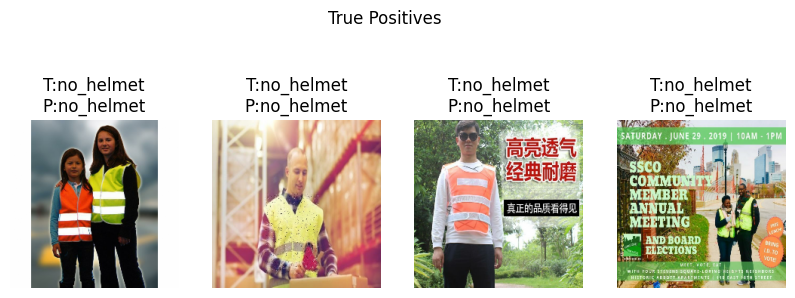

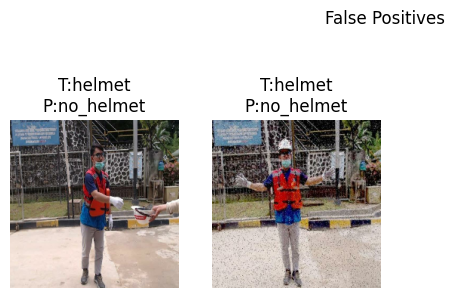

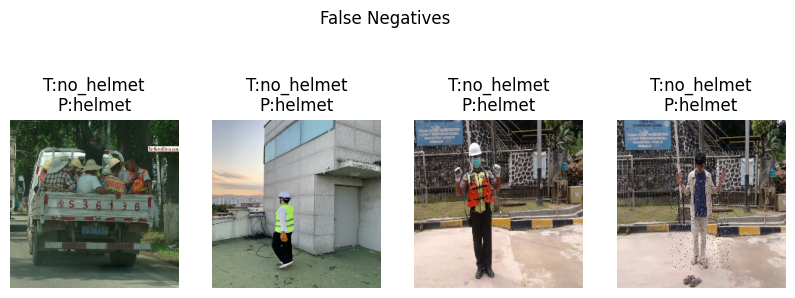

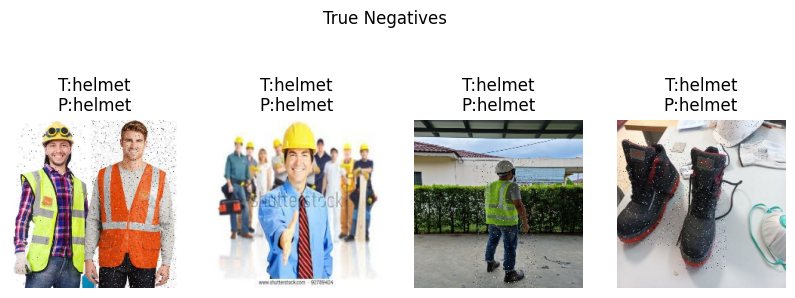

In [25]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    if num_classes == 2:
        preds_cls = (preds.ravel() > 0.5).astype("int32")
    else:
        preds_cls = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_cls)

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))


# ============================================================
# TP / FP / FN / TN Visualisation
# ============================================================

def visualize_confusion_examples(model, test_ds, class_names, max_images=4):
    images_list = []
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images)
        preds_cls = (preds.ravel() > 0.5).astype("int32") if len(class_names)==2 else np.argmax(preds, axis=1)
        images_list.extend(images.numpy())
        y_true.extend(labels.numpy())
        y_pred.extend(preds_cls)

    images_list = np.array(images_list)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp_idx = np.where((y_true == 1) & (y_pred == 1))[0]
    fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    tn_idx = np.where((y_true == 0) & (y_pred == 0))[0]

    groups = {
        "True Positives": tp_idx,
        "False Positives": fp_idx,
        "False Negatives": fn_idx,
        "True Negatives": tn_idx
    }

    for title, idxs in groups.items():
        plt.figure(figsize=(10, 4))
        plt.suptitle(title)
        for i, idx in enumerate(idxs[:max_images]):
            plt.subplot(1, max_images, i+1)
            plt.imshow((images_list[idx] + 1) / 2.0)
            plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
            plt.axis("off")
        plt.show()


visualize_confusion_examples(model, test_ds, class_names)

##External Image Inference

his Python function, predict_external_image, is designed to take the path to an image file, load it, preprocess it, and then use your trained Keras model to predict its class (whether it's 'helmet' or 'no_helmet' in this case).

img = keras_image.load_img(path, target_size=IMG_SIZE): This line uses Keras's image utility to load the image from the given path. It also resizes the image to IMG_SIZE (which is (224, 224) pixels, a common input size for MobileNetV2).
img_arr = keras_image.img_to_array(img): The loaded image is converted into a NumPy array of pixel values.
img_arr = preprocess_input(img_arr): This is a crucial step for using pre-trained models like MobileNetV2. preprocess_input scales the pixel values of the image to the range [-1, 1], which is what the MobileNetV2 model expects as input, based on how it was originally trained.
img_arr = np.expand_dims(img_arr, axis=0): Keras models expect input in batches. Even if you're predicting for a single image, you need to wrap it in an extra dimension to represent a batch of one image. This line changes the shape from (height, width, channels) to (1, height, width, channels).
preds = model.predict(img_arr): The preprocessed image (now in the correct format) is passed to the model.predict() method. This will return the raw prediction output from your model.
Determining the Class:
if num_classes == 2:: Since your model is a binary classifier (predicting between 'helmet' and 'no_helmet'), it uses a sigmoid activation function in the final layer, outputting a single value between 0 and 1. If this value is greater than 0.5, it's classified as 1 (which corresponds to 'no_helmet' in your class_names list); otherwise, it's 0 ('helmet').
else: cls = np.argmax(preds): If num_classes were greater than 2 (a multi-class classification problem), the model would typically use a softmax activation, outputting probabilities for each class. np.argmax(preds) would then select the class with the highest predicted probability.
return class_names[cls]: Finally, it uses the determined class index (cls) to fetch the actual class name from your class_names list and returns it.

In [ ]:
def predict_external_image(path):
    img = keras_image.load_img(path, target_size=IMG_SIZE)
    img_arr = keras_image.img_to_array(img)
    img_arr = preprocess_input(img_arr)
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr)
    if num_classes == 2:
        cls = int(preds.ravel() > 0.5)
    else:
        cls = np.argmax(preds)

    return class_names[cls]

##Grad-CAM

This code block implements Grad-CAM (Gradient-weighted Class Activation Mapping), a powerful technique used to understand which parts of an image a Convolutional Neural Network (CNN) focuses on when making a prediction. It helps to visualize the 'reasoning' behind the model's output.

Extracting the Base Model and Last Convolutional Layer:

base_model = model.get_layer("mobilenetv2_1.00_224"): This line retrieves the pre-trained MobileNetV2 part of your fine-tuned model. Grad-CAM works by analyzing the gradients flowing into the last convolutional layer of the base model.
last_conv_layer = base_model.get_layer("Conv1"): This identifies the specific last convolutional layer within the base_model from which to extract feature maps.
backbone_gc = tf.keras.Model(...): A new tf.keras.Model is created. This backbone_gc model takes the same input as the original base_model but outputs the activations from the last_conv_layer. This is crucial because Grad-CAM needs these feature maps and the gradients with respect to them.
make_gradcam_heatmap(img_array, backbone_gc) Function:

This function generates the raw Grad-CAM heatmap.
with tf.GradientTape() as tape:: A GradientTape is used to record operations for automatic differentiation. This allows us to compute gradients later.
conv_outputs = backbone_gc(img_array): The input image is passed through the backbone_gc model to get the feature maps from the last_conv_layer.
score = tf.reduce_mean(conv_outputs): In a classification context, score usually refers to the prediction for the target class. Here, it simplifies to the mean of the convolutional outputs, which is used to calculate the gradients.
grads = tape.gradient(score, conv_outputs): This is the core of Grad-CAM. It computes the gradients of the score (representing the model's 'attention' to the feature maps) with respect to the conv_outputs (the feature maps themselves). These gradients indicate how much each feature map activation influences the final score.
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)): The gradients are then globally averaged across their spatial dimensions (height, width) and batch dimension to get a single weight for each filter in the last convolutional layer. These weights represent the importance of each filter for the decision.
heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]: The importance weights (pooled_grads) are linearly combined (dot product) with the feature maps (conv_outputs) to produce a raw heatmap. The [..., tf.newaxis] reshapes pooled_grads for broadcasting.
heatmap = tf.squeeze(heatmap): Removes any singleton dimensions.
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap): The heatmap is then rectified (only positive values are kept, as negative values indicate features that are detrimental to the class) and normalized to a range between 0 and 1. This gives a clear indication of relevant areas.
return heatmap.numpy(): Returns the heatmap as a NumPy array.
display_gradcam(image, heatmap, alpha=0.4) Function:

This function takes the original image and the generated heatmap and superimposes them for visualization.
img = (image + 1) / 2.0: The input image, which was preprocessed (likely normalized to [-1, 1] by preprocess_input), is converted back to a [0, 1] range for proper display.
heatmap = np.uint8(255 * heatmap): The heatmap (0-1 range) is scaled to 0-255 and converted to an 8-bit integer, suitable for image processing.
heatmap = tf.image.resize(...): The heatmap is upsampled to the original image's dimensions, as it was generated from a lower-resolution convolutional layer output.
heatmap = np.repeat(heatmap, 3, axis=-1): The single-channel heatmap is replicated across 3 channels to make it compatible for overlaying on a color image.
superimposed = heatmap * alpha + img * 255: The heatmap is then overlaid onto the original image. alpha controls the transparency of the heatmap.
plt.figure(...), plt.imshow(...), plt.show(): Standard Matplotlib code to display the resulting image with the Grad-CAM overlay.
Example Usage:

The last few lines demonstrate how to use these functions:
It takes one image (img) from your test_ds.
Generates a heatmap for that image using make_gradcam_heatmap.
Displays the heatmap superimposed on the img using display_gradcam.
In summary, this code provides a way to visually inspect where your CNN model is looking in an image to classify it, which is invaluable for debugging, understanding, and building trust in your model.

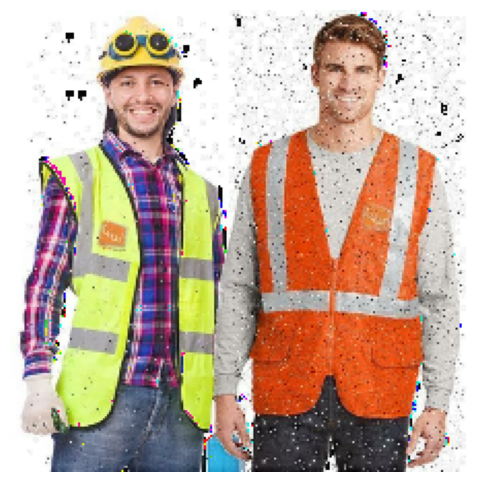

In [ ]:
base_model = model.get_layer("mobilenetv2_1.00_224")
last_conv_layer = base_model.get_layer("Conv1")

backbone_gc = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

def make_gradcam_heatmap(img_array, backbone_gc):
    with tf.GradientTape() as tape:
        conv_outputs = backbone_gc(img_array)
        score = tf.reduce_mean(conv_outputs)

    grads = tape.gradient(score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(image, heatmap, alpha=0.4):
    img = (image + 1) / 2.0
    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (img.shape[0], img.shape[1])
    ).numpy()
    heatmap = np.repeat(heatmap, 3, axis=-1)
    superimposed = heatmap * alpha + img * 255
    superimposed = np.uint8(superimposed)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.axis("off")
    plt.show()

for images, labels in test_ds.take(1):
    img = images[0:1]
    break

heatmap = make_gradcam_heatmap(img, backbone_gc)
display_gradcam(img[0], heatmap)

#End of the Notebook


